# Flood Risk Monitoring and Mitigation

This notebook demonstrates the `flood` module using an approximate Niger River
AOI and the 2022 flood event windows used by the package defaults. The workflow
combines terrain, Sentinel-1 SAR change, rainfall, surface water, and land-cover
features to produce a four-class risk map and model explanations.


## Before you run

Configure Earth Engine as described in the project README. Flood analysis uses
several event-specific windows; replace all of them together when studying a
different event. Smaller `n_pixels` values are useful for a quick exploratory run.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError(
        "Set GEE_PROJECT in your shell or in the repository .env file before running this notebook."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

In [2]:
module_info = USE_CASE_REGISTRY["flood"]
print(module_info.name)
print(module_info.date_guidance)
print("Models:", [option.id for option in module_info.model_options])

Flood Risk Monitoring & Mitigation
Select a rainy season period for best results (e.g., March–May or Oct–Dec)
Models: ['rf', 'xgboost', 'ensemble']


In [3]:
# Approximate Niger River floodplain near Niamey, Niger.
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [1.80, 13.20],
            [2.60, 13.20],
            [2.60, 13.80],
            [1.80, 13.80],
            [1.80, 13.20],
        ]
    ],
}

analysis_args = {
    "module": "flood",
    "aoi_geojson": aoi,
    "start_date": "2022-01-01",
    "end_date": "2023-01-31",
    "country": "Niger",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "ensemble",  # "rf", "xgboost", or "ensemble"
        "flood_event": "Niger River flood pulse, 2022",
        "pre_flood_start": "2022-05-01",
        "pre_flood_end": "2022-07-31",
        "post_flood_start": "2022-10-01",
        "post_flood_end": "2023-01-31",
        "rain_7d_start": "2022-08-18",
        "rain_7d_end": "2022-08-25",
        "rain_30d_start": "2022-08-01",
        "rain_30d_end": "2022-08-31",
        "mndwi_start": "2022-10-01",
        "mndwi_end": "2023-01-31",
        "flood_label_start": "2021-01-01",
        "flood_label_end": "2021-12-31",
        "n_pixels": 3000,
        "scale": 90,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "niger_flood_2022",
    },
}

In [4]:
output = await run_analysis(**analysis_args)

2026-06-24 13:57:24,650 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/odero-george/workspace/climate-change/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44347 instead
  warnings.warn(
2026-06-24 13:57:24,672 - distributed.scheduler - INFO - State start
2026-06-24 13:57:24,675 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:34151
2026-06-24 13:57:24,676 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:44347/status
2026-06-24 13:57:24,677 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-24 13:57:24,687 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33151'
2026-06-24 13:57:24,689 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34323'
2

In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Chart keys:", sorted(output.charts))
print("Metadata:", output.metadata)
output.stats

Module: flood
Raster output: {'flood_risk': '/home/odero-george/workspace/climate-change/outputs/niger_flood_2022_flood_risk.tif'}
GeoJSON features: 16
Chart keys: ['model_performance', 'risk_distribution', 'shap', 'uncertainty']
Metadata: {'model': 'ensemble', 'country': 'Niger', 'start_date': '2022-01-01', 'end_date': '2023-01-31', 'raster': {'flood_risk': '/home/odero-george/workspace/climate-change/outputs/niger_flood_2022_flood_risk.tif'}, 'windows': {'pre_flood': {'start': '2022-05-01', 'end': '2022-07-31'}, 'post_flood': {'start': '2022-10-01', 'end': '2023-01-31'}, 'rainfall_7d': {'start': '2022-08-18', 'end': '2022-08-25'}, 'rainfall_30d': {'start': '2022-08-01', 'end': '2022-08-31'}, 'mndwi': {'start': '2022-10-01', 'end': '2023-01-31'}}}


{'model_type': 'ensemble',
 'n_pixels_sampled': 74,
 'flooded_pct': 55.4,
 'rf_cv_f1': 0.6936,
 'rf_f1': 0.8,
 'rf_auc': 0.5714,
 'xgb_cv_f1': 0.6447,
 'xgb_f1': 0.7273,
 'xgb_auc': 0.5,
 'ensemble_f1': 0.7619,
 'ensemble_auc': 0.5357,
 'selected_f1': 0.7619,
 'selected_auc': 0.5357,
 'selected_threshold': 0.2965,
 'top_flood_driver': 'dist_river',
 'very_high_risk_pct': 13.4,
 'high_risk_pct': 51.8,
 'medium_risk_pct': 34.2,
 'low_risk_pct': 0.6,
 'mean_spread': 0.1733,
 'high_uncertainty_pct': 40.0,
 'spread_stats': {'min': 0.0111,
  'p25': 0.1011,
  'p75': 0.265,
  'max': 0.3189,
  'mean': 0.1733},
 'very_high_risk_pixels': 98430,
 'high_risk_pixels': 379737,
 'medium_risk_pixels': 250645,
 'low_risk_pixels': 4284,
 'mapped_pixel_count': 733096,
 'country': 'Niger'}

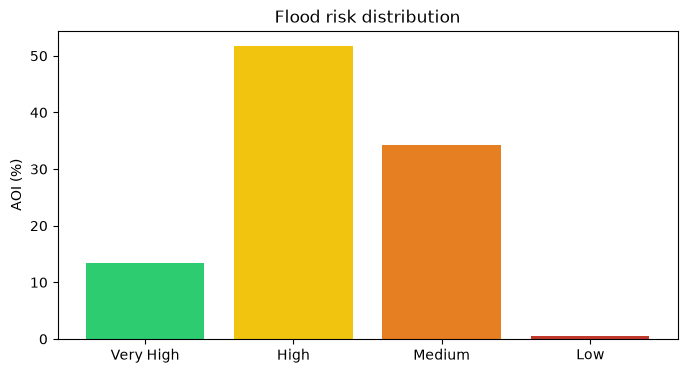

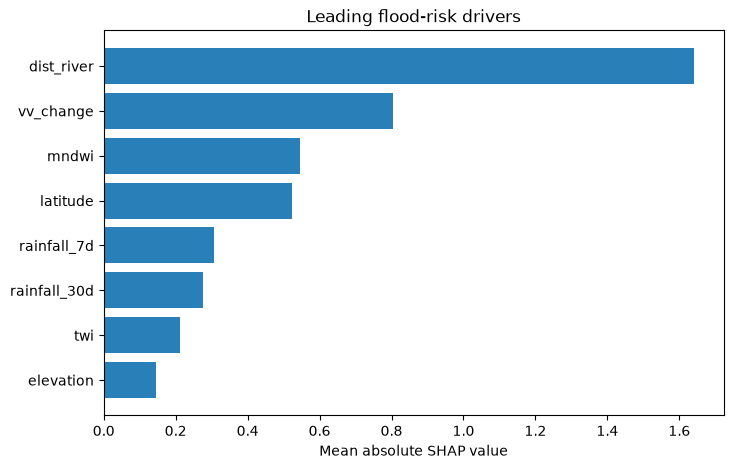

In [6]:
risk = output.charts.get("risk_distribution", {})
if risk.get("labels"):
    colors = ["#2ECC71", "#F1C40F", "#E67E22", "#C0392B"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(risk["labels"], risk["data"], color=colors[: len(risk["labels"])])
    ax.set_ylabel("AOI (%)")
    ax.set_title("Flood risk distribution")
    plt.show()

shap = output.shap or output.charts.get("shap", {})
if shap.get("features"):
    features = shap["features"][:8][::-1]
    values = shap["mean_abs_shap"][:8][::-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(features, values, color="#2980B9")
    ax.set_title("Leading flood-risk drivers")
    ax.set_xlabel("Mean absolute SHAP value")
    plt.show()

In [7]:
# Optional: generate a PDF report in a second call.
# Set this to True only when you want the extra analysis/report run.
GENERATE_REPORT = False

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/flood_20260624_105745.pdf
